## Build a Tic-Tac-Toe game using reinforcement learning in Python by using following tasks

1. Setting up the environment
2. Defining the Tic-Tac-Toe game
3. Building the reinforcement learning model
4. Training the model
5. Testing the model

## Reinforcement learning (RL)
It is a machine learning technique where an intelligent "agent" learns optimal behavior through trial and error by interacting with an "environment" to maximize a "reward signal". 

## Key Components of Reinforcement Learning

- **Agent**: The decision-maker or learner that interacts with the environment.  
- **Environment**: The world or system in which the agent operates and performs actions.  
- **State**: The current situation or condition of the environment that the agent perceives.  
- **Action**: The possible moves or decisions the agent can make in a given state.  
- **Reward**: The feedback signal from the environment that indicates the quality of an action, guiding the agent to learn desired behaviors.  


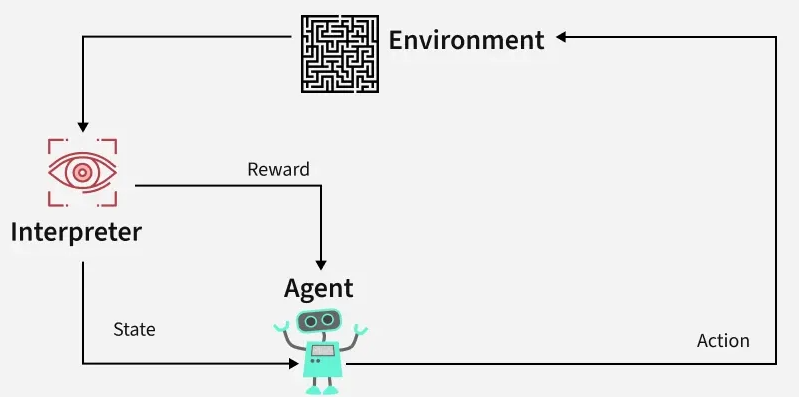

In [3]:
import numpy as np
import random
from collections import defaultdict

## 2. Tic-Tac-Toe Environment

A simple class to handle the game logic.

In [9]:
def init_board():
    return [' '] * 9

def available_moves(board):
    return [i for i, x in enumerate(board) if x == ' ']

def check_winner(board, player):
    wins = [(0,1,2), (3,4,5), (6,7,8), (0,3,6), (1,4,7), (2,5,8), (0,4,8), (2,4,6)]
    return any(all(board[i] == player for i in line) for line in wins)

def print_board(board):
    for i in range(3):
        print(board[i*3:(i+1)*3])
    print()


## 3. Q-Learning Agent

Agent that learns which moves are best.

In [10]:
class QAgent:
    def __init__(self):
        self.q = defaultdict(lambda: np.zeros(9))
        self.eps = 0.1
        self.lr = 0.5
        self.gamma = 0.9

    def choose_action(self, state, actions):
        if random.random() < self.eps:
            return random.choice(actions)
        q_vals = [self.q[state][a] if a in actions else -np.inf for a in range(9)]
        return int(np.argmax(q_vals))

    def learn(self, s, a, r, s_, done, actions_):
        target = r if done else r + self.gamma * max([self.q[s_][a] for a in actions_])
        self.q[s][a] += self.lr * (target - self.q[s][a])


## 4. Training the Agent

Train the agent by playing many games against a random opponent.

In [11]:
def train(agent, episodes=10000):
    for _ in range(episodes):
        board = init_board()
        state = tuple(board)
        done = False

        while not done:
            actions = available_moves(board)
            action = agent.choose_action(state, actions)
            board[action] = 'X'

            if check_winner(board, 'X'):
                agent.learn(state, action, 1, tuple(board), True, [])
                break

            if ' ' not in board:
                agent.learn(state, action, 0, tuple(board), True, [])
                break

            opp_actions = available_moves(board)
            opp_action = random.choice(opp_actions)
            board[opp_action] = 'O'

            if check_winner(board, 'O'):
                agent.learn(state, action, -1, tuple(board), True, [])
                break

            next_state = tuple(board)
            agent.learn(state, action, 0, next_state, False, available_moves(board))
            state = next_state


## 5. Human vs Agent Play

In [12]:
def play(agent):
    board = init_board()
    print("Board positions: 0 1 2\n                 3 4 5\n                 6 7 8\n")

    while True:
        print_board(board)
        # Human Move
        human_move = -1
        while human_move not in available_moves(board):
            try:
                human_move = int(input("Your move (0-8): "))
            except:
                continue
        board[human_move] = 'O'

        if check_winner(board, 'O'):
            print_board(board)
            print("You win!")
            break

        if ' ' not in board:
            print_board(board)
            print("It's a draw!")
            break

        # Agent Move
        state = tuple(board)
        agent_move = int(np.argmax(agent.q[state]))
        if agent_move not in available_moves(board):
            agent_move = random.choice(available_moves(board))
        board[agent_move] = 'X'
        print(f"Agent plays: {agent_move}")

        if check_winner(board, 'X'):
            print_board(board)
            print("Agent wins!")
            break

        if ' ' not in board:
            print_board(board)
            print("It's a draw!")
            break


## 6. Run the Model

In [14]:
agent = QAgent()
print("Training agent...")
train(agent)
print("Training complete. Let's play!\n")

Training agent...
Training complete. Let's play!



In [16]:
play(agent)

Board positions: 0 1 2
                 3 4 5
                 6 7 8

[' ', ' ', ' ']
[' ', ' ', ' ']
[' ', ' ', ' ']



Your move (0-8):  1


Agent plays: 0
['X', 'O', ' ']
[' ', ' ', ' ']
[' ', ' ', ' ']



Your move (0-8):  4


Agent plays: 7
['X', 'O', ' ']
[' ', 'O', ' ']
[' ', 'X', ' ']



...

Agent plays: 2
['X', 'O', 'X']
[' ', 'O', ' ']
['O', 'X', ' ']



Your move (0-8):  8


Agent plays: 3
['X', 'O', 'X']
['X', 'O', ' ']
['O', 'X', 'O']



Your move (0-8):  5


['X', 'O', 'X']
['X', 'O', 'O']
['O', 'X', 'O']

It's a draw!
